In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import torch
from torch import nn
import copy

# Fitting

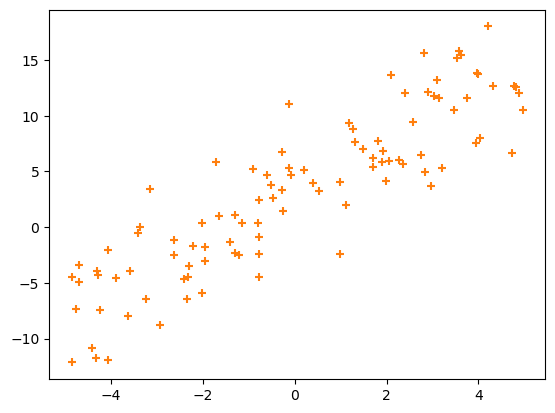

In [12]:
# uniformly random x values
x = np.random.uniform(-5, 5, 100)

# linear (2 * x + 3) plus normal-distributed noise
y = (2 * x + 3) + np.random.normal(0, 3, 100)

fig, ax = plt.subplots()
ax.scatter(x, y, marker="+", color="tab:orange")
plt.show()

# Using an exact mathematical formula for linear regression


In [7]:
# Generate 1D data: y = 2x + 3 + noise
x = np.random.uniform(-5, 5, 100)
y = (2 * x + 3) + np.random.normal(0, 3, 100)

# Scikit-Learn wants an array of vectors: (N, 1)
X_sklearn = x.reshape(-1, 1)

model = LinearRegression().fit(X_sklearn, y)
a = model.coef_[0]
b = model.intercept_

print(f"Fit results: slope (a) = {a:.2f}, intercept (b) = {b:.2f}")

Fit results: slope (a) = 1.92, intercept (b) = 3.40


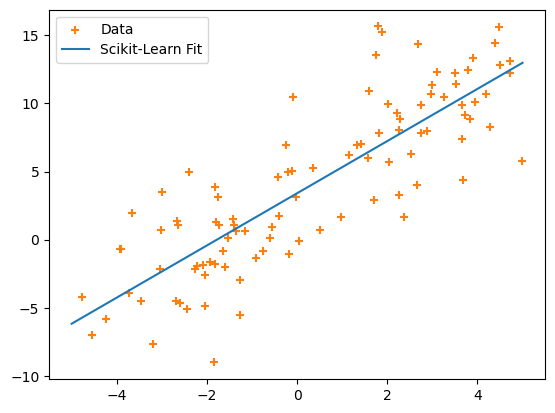

In [8]:
#Visualization
fig, ax = plt.subplots()
ax.scatter(x, y, marker="+", color="tab:orange", label="Data")
ax.plot([-5, 5], [a*-5 + b, a*5 + b], color="tab:blue", label="Scikit-Learn Fit")
ax.legend()
plt.show()

# Exercise 1: Spend 15 mins going through: https://hsf-training.github.io/deep-learning-intro-for-hep/03-basic-fitting.html

# Using gradient descent to find parameters but still using the mathematical relation, no neural network yet

In [9]:
# Convert data to PyTorch tensors
x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# Initialize parameters randomly
w = torch.randn(1, requires_grad=True)
b_param = torch.randn(1, requires_grad=True)

optimizer = torch.optim.Adam([w, b_param], lr=0.1)
loss_fn = nn.MSELoss()

for epoch in range(200):
    optimizer.zero_grad()
    
    # Prediction: y = wx + b
    pred = x_tensor * w + b_param
    loss = loss_fn(pred, y_tensor)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

print(f"\nGD results: w = {w.item():.2f}, b = {b_param.item():.2f}")

Epoch 0: Loss = 48.1713
Epoch 50: Loss = 11.2019
Epoch 100: Loss = 11.1355
Epoch 150: Loss = 11.1347

GD results: w = 1.92, b = 3.40


# Using a NN, this doesn't require us to guess the mathematical relationship, it can be learnt during training

In [14]:
# Define a simple model: one linear layer
model = nn.Linear(in_features=1, out_features=1)

optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
loss_fn = nn.MSELoss()

for epoch in range(200):
    optimizer.zero_grad()
    
    # Forward pass
    pred = model(x_tensor)
    loss = loss_fn(pred, y_tensor)
    
    # Backward pass and optimization
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

w_fitted = model.weight.item()
b_fitted = model.bias.item()
print(f"\nNN results: w = {w_fitted:.2f}, b = {b_fitted:.2f}")

Epoch 0: Loss = 41.4139
Epoch 50: Loss = 11.1696
Epoch 100: Loss = 11.1353
Epoch 150: Loss = 11.1347

NN results: w = 1.92, b = 3.40


## Exercise 2: Understand the code, make plot visualizing the fit (like above) for the 2 cases (10 mins)

## Exercise 3: Play around with NNs to get an intuition -- https://hsf-training.github.io/deep-learning-intro-for-hep/06-exercise-1.html (15 mins)

# The need for non-linearity

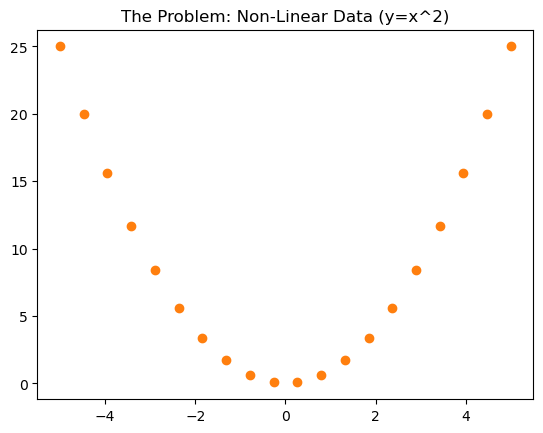

In [13]:
# Generate non-linear data: y = x^2
x_nonlin = np.linspace(-5, 5, 20)
y_nonlin = x_nonlin**2

x_nonlin_t = torch.tensor(x_nonlin, dtype=torch.float32).unsqueeze(1)
y_nonlin_t = torch.tensor(y_nonlin, dtype=torch.float32).unsqueeze(1)

plt.scatter(x_nonlin, y_nonlin, color="tab:orange")
plt.title("The Problem: Non-Linear Data (y=x^2)")
plt.show()

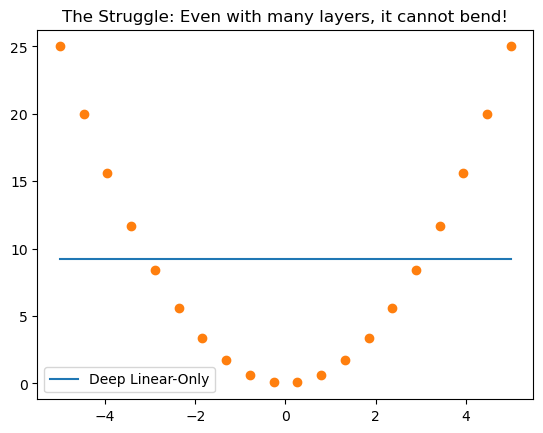

In [15]:
# A deeper model, but still WITH NO non-linearity
linear_only_model = nn.Sequential(
    nn.Linear(1, 64),
    #nn.Linear(64, 64),
    #nn.Linear(64, 64),
    nn.Linear(64, 1)
)

optimizer = torch.optim.Adam(linear_only_model.parameters(), lr=0.1)
for epoch in range(500):
    optimizer.zero_grad()
    loss = nn.MSELoss()(linear_only_model(x_nonlin_t), y_nonlin_t)
    loss.backward()
    optimizer.step()

pred_lin = linear_only_model(x_nonlin_t).detach().numpy()

plt.scatter(x_nonlin, y_nonlin, color="tab:orange")
plt.plot(x_nonlin, pred_lin, color="tab:blue", label="Deep Linear-Only")
plt.legend()
plt.title("The Struggle: Even with many layers, it cannot bend!")
plt.show()

## Exercise 4: Does increasing model capacity improve fitting? uncomment the lines above and add a few more to see

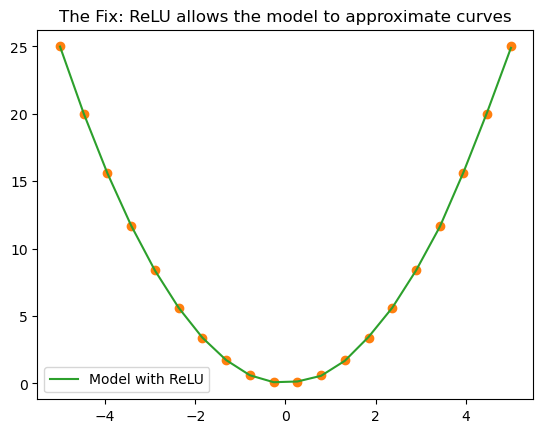

In [18]:
# The same model, but WITH ReLU activation
relu_model = nn.Sequential(
    nn.Linear(1, 64),
    nn.ReLU(),  # <-- The Magic
    nn.Linear(64, 1)
)

optimizer = torch.optim.Adam(relu_model.parameters(), lr=0.1)
for epoch in range(500):
    optimizer.zero_grad()
    loss = nn.MSELoss()(relu_model(x_nonlin_t), y_nonlin_t)
    loss.backward()
    optimizer.step()

pred_relu = relu_model(x_nonlin_t).detach().numpy()

plt.scatter(x_nonlin, y_nonlin, color="tab:orange")
plt.plot(x_nonlin, pred_relu, color="tab:green", label="Model with ReLU")
plt.legend()
plt.title("The Fix: ReLU allows the model to approximate curves")
plt.show()